# Task 6 — House Price Prediction (Regression)

## Goal
Predict **sale prices** from property features (size, bedrooms, basement area, **location/neighborhood**).

This notebook follows a standard ML workflow: **EDA → preprocessing → scaling & feature selection → train two regressors → evaluate (MAE, RMSE) → visualize actual vs predicted** and summarize **insights** (including feature importance from the tree model).

**Dataset:** `house_price_dataset.csv` — structured like the [Kaggle *House Prices*](https://www.kaggle.com/c/house-prices-advanced-regression-techniques) competition (numeric + neighborhood). The bundled file is generated for reproducible offline runs; you may replace it with Kaggle `train.csv` after selecting the same columns (`GrLivArea`, `BedroomAbvGr`, `TotalBsmtSF`, `Neighborhood`, `SalePrice`).


In [3]:
# --- Configuration & imports ---
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [4]:
def find_house_price_csv() -> Path:
    """Resolve dataset path whether the notebook cwd is this folder or repo root."""
    here = Path.cwd()
    candidates = [
        here / "house_price_dataset.csv",
        here / "Tasks" / "Task_6_House_Price" / "house_price_dataset.csv",
        here.parent / "house_price_dataset.csv",
        here.parent.parent / "Tasks" / "Task_6_House_Price" / "house_price_dataset.csv",
    ]
    for p in candidates:
        if p.is_file():
            return p.resolve()
    raise FileNotFoundError(
        "house_price_dataset.csv not found. Place it next to this notebook or under Tasks/Task_6_House_Price/."
    )


DATA_PATH = find_house_price_csv()
print("Using:", DATA_PATH)


Using: /content/house_price_dataset.csv


## 1. Load data

We expect:
- **`GrLivArea`** — above-ground living area (square feet)
- **`BedroomAbvGr`** — bedrooms above grade
- **`TotalBsmtSF`** — total basement square footage (extra size signal)
- **`Neighborhood`** — location (categorical)
- **`SalePrice`** — target (USD)


In [5]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (1460, 5)


,GrLivArea,BedroomAbvGr,Neighborhood,TotalBsmtSF,SalePrice
0,2001,3,Veenker,237,185136
1,1390,1,SawyerW,941,125145
2,1036,4,Gilbert,115,113837
3,1474,1,OldTown,437,101421
4,1972,4,OldTown,712,140622


In [6]:
# Basic integrity checks
assert df["SalePrice"].notna().all(), "Target must not be null"
print("Missing values per column:\n", df.isna().sum())


Missing values per column:
 GrLivArea       0
BedroomAbvGr    0
Neighborhood    0
TotalBsmtSF     0
SalePrice       0
dtype: int64


## 2. Exploratory Data Analysis (EDA)

We inspect distributions, correlations, and how **price** relates to **size** and **location**.


,count,mean,std,min,25%,50%,75%,max
GrLivArea,1460.0,1478.341096,444.791676,480.0,1179.00,1499.0,1773.75,2930.0
BedroomAbvGr,1460.0,2.991781,1.403975,1.0,2.00,3.0,4.00,5.0
TotalBsmtSF,1460.0,906.007534,345.281102,0.0,665.75,903.0,1126.25,2109.0
SalePrice,1460.0,145668.373973,34248.872240,60051.0,120853.50,142042.0,167502.75,270702.0


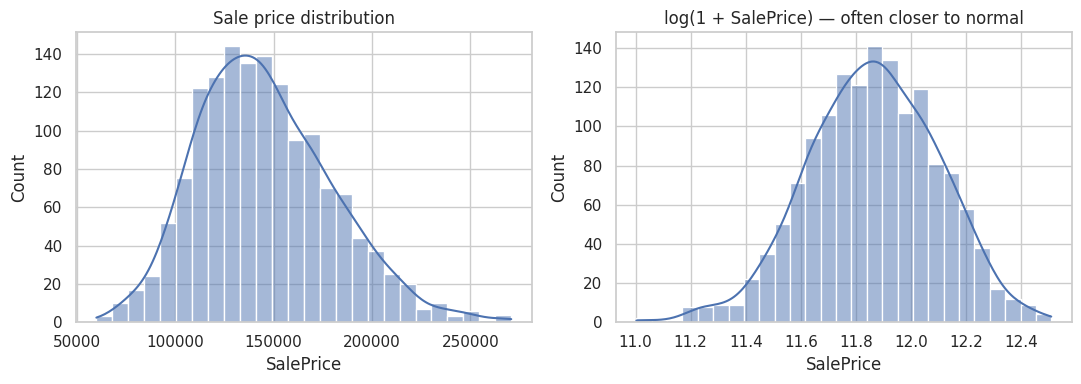

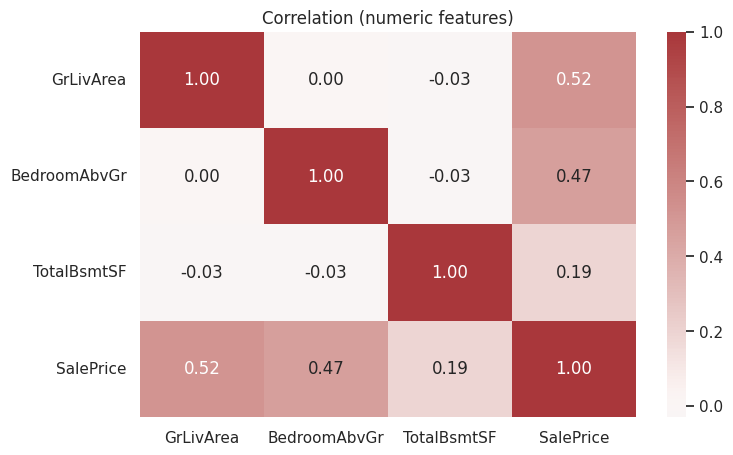

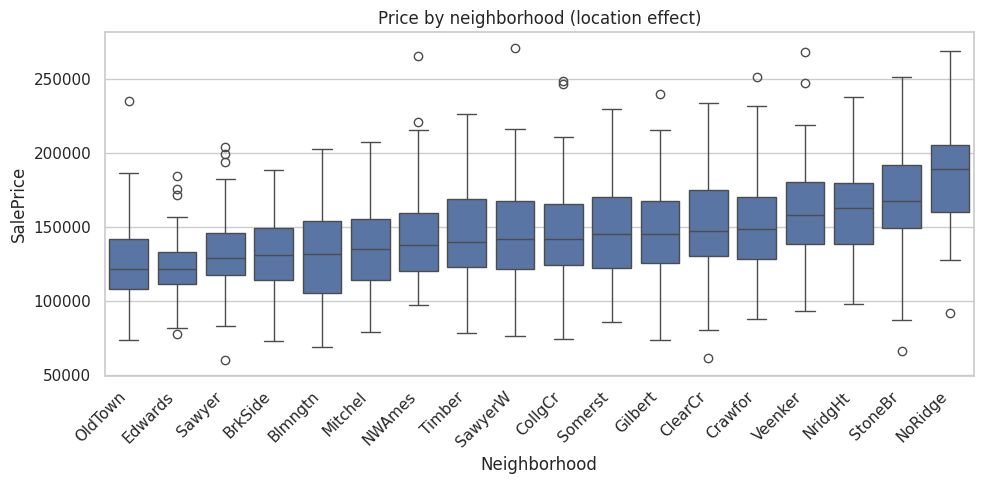

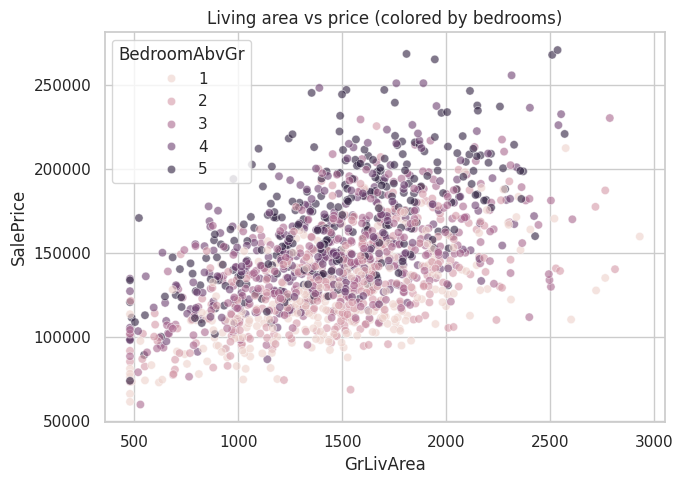

In [7]:
def run_eda(data: pd.DataFrame) -> None:
    """EDA summaries and plots (modular)."""
    display(data.describe().T)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.histplot(data["SalePrice"], kde=True, ax=axes[0])
    axes[0].set_title("Sale price distribution")
    sns.histplot(np.log1p(data["SalePrice"]), kde=True, ax=axes[1])
    axes[1].set_title("log(1 + SalePrice) — often closer to normal")
    plt.tight_layout()
    plt.show()

    num_cols = ["GrLivArea", "BedroomAbvGr", "TotalBsmtSF", "SalePrice"]
    corr = data[num_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title("Correlation (numeric features)")
    plt.show()

    plt.figure(figsize=(10, 5))
    order = data.groupby("Neighborhood")["SalePrice"].median().sort_values().index
    sns.boxplot(data=data, x="Neighborhood", y="SalePrice", order=order)
    plt.xticks(rotation=45, ha="right")
    plt.title("Price by neighborhood (location effect)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=data, x="GrLivArea", y="SalePrice", hue="BedroomAbvGr", alpha=0.6)
    plt.title("Living area vs price (colored by bedrooms)")
    plt.tight_layout()
    plt.show()


run_eda(df)


## 3. Preprocessing

**Square footage:** we use `GrLivArea` and `TotalBsmtSF` as continuous size signals (standardized later).

**Bedrooms:** numeric `BedroomAbvGr`.

**Location:** `Neighborhood` is **one-hot encoded** (each area becomes its own binary column).

**Outliers:** extreme living areas can distort linear models; we cap rare tails using **percentile clipping** on training-derived quantiles (applied consistently to train and test).


In [8]:
def clip_numeric_outliers(
    train: pd.DataFrame,
    test: pd.DataFrame,
    cols: list[str],
    lower_q: float = 0.005,
    upper_q: float = 0.995,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Winsorize selected numeric columns using quantiles from `train` only."""
    train_o = train.copy()
    test_o = test.copy()
    for c in cols:
        lo = train_o[c].quantile(lower_q)
        hi = train_o[c].quantile(upper_q)
        train_o[c] = train_o[c].clip(lo, hi)
        test_o[c] = test_o[c].clip(lo, hi)
    return train_o, test_o


def preprocess_features(X_train: pd.DataFrame, X_test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Handle size columns + categorical location."""
    X_tr = X_train.copy()
    X_te = X_test.copy()
    X_tr["Neighborhood"] = X_tr["Neighborhood"].astype("category")
    X_te["Neighborhood"] = X_te["Neighborhood"].astype("category")
    size_cols = ["GrLivArea", "TotalBsmtSF"]
    X_tr, X_te = clip_numeric_outliers(X_tr, X_te, size_cols)
    return X_tr, X_te


In [9]:
# Train / test split (scaling is fit on train only — inside the pipeline)
feature_cols = ["GrLivArea", "BedroomAbvGr", "TotalBsmtSF", "Neighborhood"]
target_col = "SalePrice"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train, X_test = preprocess_features(X_train, X_test)
print(X_train.shape, X_test.shape)


(1168, 4) (292, 4)


## 4. Feature scaling & selection

- **Scaling:** `StandardScaler` on numeric columns so features with different units contribute fairly in linear models.
- **Location:** `OneHotEncoder(handle_unknown='ignore')` for neighborhoods.
- **Selection:** `SelectKBest` with `f_regression` keeps the top *K* transformed features most associated with the target (linear association score).


In [10]:
NUMERIC_FEATURES = ["GrLivArea", "BedroomAbvGr", "TotalBsmtSF"]
CATEGORICAL_FEATURES = ["Neighborhood"]


def build_column_transformer() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
    )


def count_encoded_features(ct: ColumnTransformer, X_sample: pd.DataFrame) -> int:
    return ct.fit_transform(X_sample).shape[1]


prep_probe = build_column_transformer()
n_feat = count_encoded_features(prep_probe, X_train)
K_BEST = min(15, n_feat)
print(f"Features after encoding: {n_feat}; SelectKBest k={K_BEST}")


Features after encoding: 21; SelectKBest k=15


In [11]:
def rmse(y_true, y_pred) -> float:
    return float(mean_squared_error(y_true, y_pred) ** 0.5)


def build_pipeline(regressor) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", build_column_transformer()),
            ("select", SelectKBest(score_func=f_regression, k=K_BEST)),
            ("reg", regressor),
        ]
    )


lin_pipe = build_pipeline(LinearRegression())
gbr_pipe = build_pipeline(
    GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        max_depth=3,
        n_estimators=300,
        learning_rate=0.06,
        subsample=0.9,
    )
)

lin_pipe.fit(X_train, y_train)
gbr_pipe.fit(X_train, y_train)

pred_lin = lin_pipe.predict(X_test)
pred_gbr = gbr_pipe.predict(X_test)

metrics = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Gradient Boosting"],
        "MAE": [
            mean_absolute_error(y_test, pred_lin),
            mean_absolute_error(y_test, pred_gbr),
        ],
        "RMSE": [rmse(y_test, pred_lin), rmse(y_test, pred_gbr)],
    }
)
metrics["MAE"] = metrics["MAE"].round(2)
metrics["RMSE"] = metrics["RMSE"].round(2)
display(metrics)


,Model,MAE,RMSE
0,Linear Regression,14556.08,18996.50
1,Gradient Boosting,15235.66,19921.46


## 5. Visualization — Predicted vs Actual

Points near the **diagonal** mean predictions match observed prices. Off-diagonal spread reflects error and model limitations.


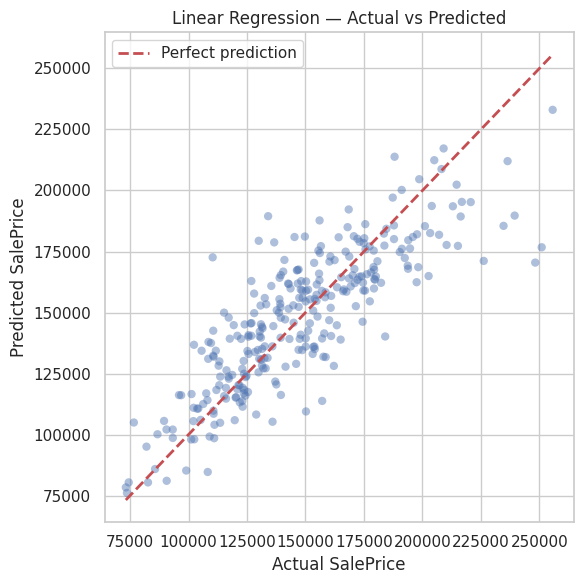

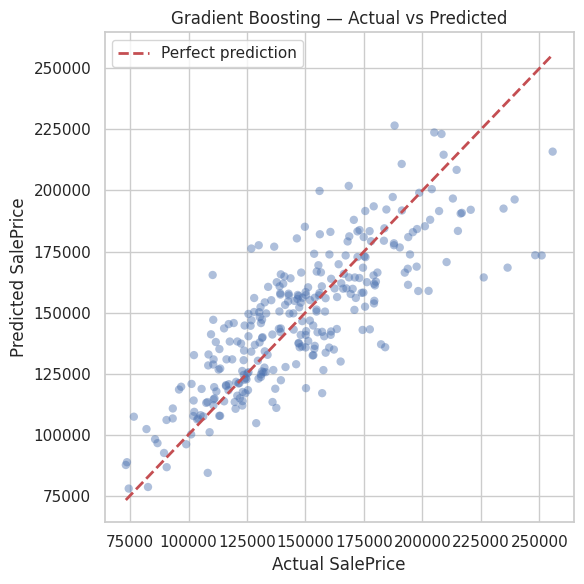

In [12]:
def plot_actual_vs_predicted(y_true, y_pred, title: str) -> None:
    plt.figure(figsize=(6, 6))
    mx = max(y_true.max(), y_pred.max())
    mn = min(y_true.min(), y_pred.min())
    plt.scatter(y_true, y_pred, alpha=0.45, edgecolors="none")
    plt.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect prediction")
    plt.xlabel("Actual SalePrice")
    plt.ylabel("Predicted SalePrice")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted(y_test, pred_lin, "Linear Regression — Actual vs Predicted")
plot_actual_vs_predicted(y_test, pred_gbr, "Gradient Boosting — Actual vs Predicted")


## 6. Feature importance & insights

**Gradient Boosting** provides `feature_importances_` over the **selected** post-encoding features. We group one-hot columns back into **location** vs **numeric** labels for readability.

**Linear Regression** coefficients are on the **scaled** space; we report absolute coefficients as a rough relative ranking (interpret with care when features are correlated).


In [13]:
def names_after_selection(pipe: Pipeline) -> np.ndarray:
    prep = pipe.named_steps["prep"]
    full = prep.get_feature_names_out()
    mask = pipe.named_steps["select"].get_support()
    return full[mask]


def summarize_gbr_importance(pipe: Pipeline) -> pd.DataFrame:
    gbr: GradientBoostingRegressor = pipe.named_steps["reg"]
    names = names_after_selection(pipe)
    imp = gbr.feature_importances_
    rows = []
    for n, w in zip(names, imp):
        if n.startswith("cat__"):
            label = "Location: " + n.replace("cat__Neighborhood_", "")
        elif n.startswith("num__"):
            label = n.replace("num__", "")
        else:
            label = n
        rows.append({"feature": label, "importance": w})
    out = pd.DataFrame(rows).groupby("feature", as_index=False)["importance"].sum()
    return out.sort_values("importance", ascending=False)


def summarize_lin_coef(pipe: Pipeline) -> pd.DataFrame:
    lin: LinearRegression = pipe.named_steps["reg"]
    names = names_after_selection(pipe)
    coef = lin.coef_
    return (
        pd.DataFrame({"feature": names, "abs_coef": np.abs(coef)})
        .assign(
            label=lambda d: d["feature"].map(
                lambda s: "Location: " + s.replace("cat__Neighborhood_", "")
                if s.startswith("cat__")
                else s.replace("num__", "")
            )
        )
        .groupby("label", as_index=False)["abs_coef"]
        .sum()
        .sort_values("abs_coef", ascending=False)
    )


display(summarize_gbr_importance(gbr_pipe).head(12))
display(summarize_lin_coef(lin_pipe).head(12))


,feature,importance
1,GrLivArea,0.401669
0,BedroomAbvGr,0.267990
14,TotalBsmtSF,0.117436
8,Location: NoRidge,0.049718
12,Location: StoneBr,0.043524
5,Location: Edwards,0.025251
9,Location: NridgHt,0.021221
10,Location: OldTown,0.016602
3,Location: BrkSide,0.014665
2,Location: Blmngtn,0.011998


,label,abs_coef
8,Location: NoRidge,33377.058316
12,Location: StoneBr,26185.247775
5,Location: Edwards,24029.724249
10,Location: OldTown,20661.184138
1,GrLivArea,18220.537606
9,Location: NridgHt,16914.224701
3,Location: BrkSide,16819.445245
0,BedroomAbvGr,16199.704758
2,Location: Blmngtn,15184.549162
13,Location: Veenker,14028.594258
